In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

Creating the directory structure to save Graphs and Output for Each Evaluator

In [3]:
output_data_path = os.path.join("output", "combined")
os.makedirs(output_data_path, exist_ok=True)

Reading the Evaluation data by Pathologist

In [4]:
evaluator_ids = ['evaluator1', 'evaluator2', 'evaluator4', 'evaluator5']
correct_answers_eval_data = []
wrong_answer_eval_data = []
for evaluator_id in evaluator_ids:
    correct_answer_eval_data_path = f"output/{evaluator_id}/pathopen_image_augmentation_correct_answer_eval_data.pkl"
    eval_data = pd.read_pickle(correct_answer_eval_data_path)
    correct_answers_eval_data.append(eval_data)

Combining all the dataframes into one combined dataframe

In [5]:
correct_answers_eval_data_combined = correct_answers_eval_data[0] + correct_answers_eval_data[1] + correct_answers_eval_data[2] + correct_answers_eval_data[3]
correct_answers_eval_data_combined

,Total,Level 2,Level 1,Level 0,Level -1
Clinical Relevance,274,237,21,7,9
Visual Grounding,274,224,30,13,7


Open-Ended Image Augmentation Graph

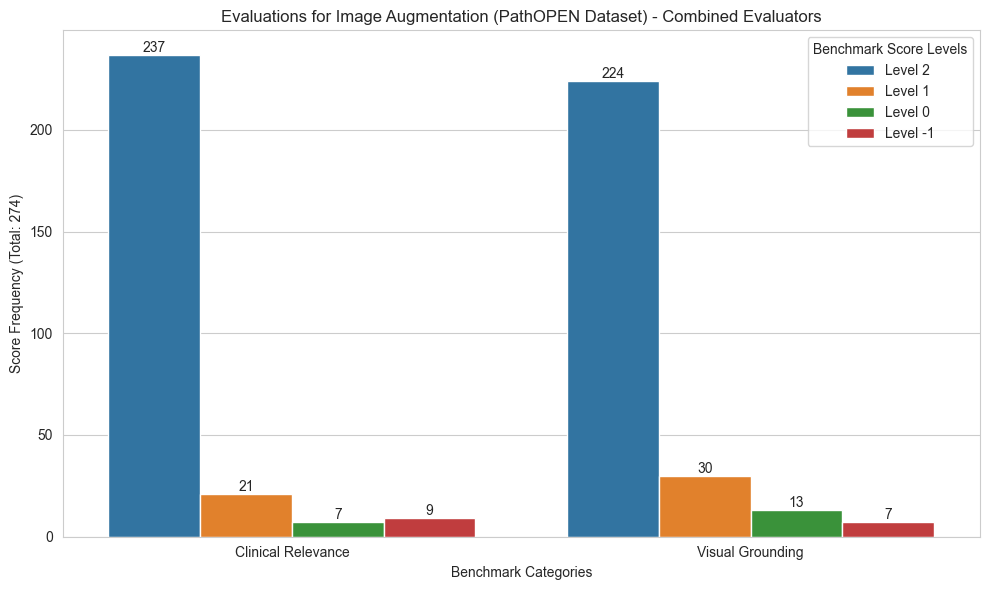

In [6]:
temp_data = correct_answers_eval_data_combined.drop(columns=['Total']).reset_index().melt(id_vars='level_0', var_name='Column Names', value_name='Values')

sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=temp_data, x='level_0', y='Values', hue='Column Names')

for container in ax.containers:
    ax.bar_label(container)
    
plt.title(f'Evaluations for Image Augmentation (PathOPEN Dataset) - Combined Evaluators')
plt.xlabel('Benchmark Categories')
plt.ylabel(f'Score Frequency (Total: {correct_answers_eval_data_combined["Total"].iloc[0]})')
plt.legend(title='Benchmark Score Levels')
plt.tight_layout()
plt.savefig(f'{output_data_path}/pathopen_image_augmentation.png')
plt.show()